In [1]:
import nashpy as nash
import numpy as np

# define game and compute nash equilibrium

# payoff matrices
U1 = np.array([[0.9, 0.2], [0.3, 0.7]])
U2 = np.array([[0.5, 0.3], [0.2, 0.7]])

game = nash.Game(U1, U2)

equilibria = game.support_enumeration()

for eq in equilibria:
    print("Player 1 strategy:", eq[0])
    print("Player 2 strategy:", eq[1])


Player 1 strategy: [1. 0.]
Player 2 strategy: [1. 0.]
Player 1 strategy: [0. 1.]
Player 2 strategy: [0. 1.]
Player 1 strategy: [0.71428571 0.28571429]
Player 2 strategy: [0.45454545 0.54545455]


In [2]:
# mixed nash equilibrium found before
pi1 = np.array([5/7, 2/7])
pi2 = np.array([5/11, 6/11])

# simulation parameters
T = 4000 # number of rounds per run
R = 300 # number of independent runs
lambda_ = 0.05
alpha = 0.2

n = 2
A_sizes = [2, 2]
threshold = sum(A_sizes)/alpha 

# storage for all runs
M1_all = np.ones((R, 2, T+1))
M2_all = np.ones((R, 2, T+1))

# run simulations
np.random.seed(0)

for r in range(R):
    M1 = np.ones((2, T+1))
    M2 = np.ones((2, T+1))
    for t in range(1, T+1):
        # sample actions
        a1 = np.random.choice([0,1], p=pi1)
        a2 = np.random.choice([0,1], p=pi2)
        # P1 martingales
        for a1_prime in [0,1]:
            X1 = U1[a1, a2] - U1[a1_prime, a2]
            M1[a1_prime, t] = M1[a1_prime, t-1] * (1 - lambda_ * X1)
        # P2 martingales
        for a2_prime in [0,1]:
            X2 = U2[a1, a2] - U2[a1, a2_prime]
            M2[a2_prime, t] = M2[a2_prime, t-1] * (1 - lambda_ * X2)
    M1_all[r] = M1
    M2_all[r] = M2

# check rejections
rejections = 0
for r in range(R):
    if np.any(M1_all[r] >= threshold) or np.any(M2_all[r] >= threshold):
        rejections += 1

fraction_rejected = rejections / R
print(f"Fraction of runs rejecting the null: {fraction_rejected:.2f}")

Fraction of runs rejecting the null: 0.01


C:\Users\etgauthi\AppData\Local\Temp\ipykernel_45392\4165928030.py:46: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


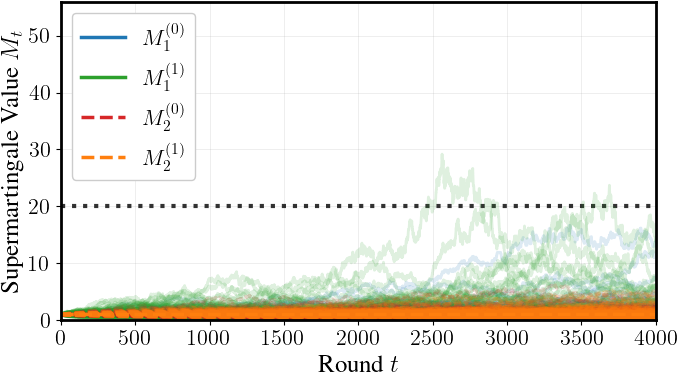

In [3]:
from tueplots import bundles
import matplotlib.pyplot as plt

# style setup
plt.rcParams.update(bundles.icml2024())
plt.rcParams.update({
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "lines.linewidth": 2,
    "axes.linewidth": 2,
})

plt.figure(figsize=(7, 4))

colors_player1 = ["#1f77b4", "#2ca02c"] 
colors_player2 = ["#d62728","#ff7f0e"] 

plt.axhline(y=threshold, color='black', linestyle=':', linewidth=3, alpha=0.8)

# P1
for a in [0,1]:
    for r in range(R):
        plt.plot(M1_all[r, a], color=colors_player1[a], alpha=0.15)
    plt.plot(M1_all[:,a,:].mean(axis=0), color=colors_player1[a], 
             label=r"$M_1^{(%d)}$" % a, linewidth=2.5)
# P2
for a in [0,1]:
    for r in range(R):
        plt.plot(M2_all[r, a], color=colors_player2[a], alpha=0.15, linestyle='--')
    plt.plot(M2_all[:,a,:].mean(axis=0), color=colors_player2[a], linestyle='--', 
             label=r"$M_2^{(%d)}$" % a, linewidth=2.5)

plt.xlabel("Round $t$")
plt.ylabel("Supermartingale Value $M_t$")

plt.legend(frameon=True, framealpha=1, loc='upper left', ncol=1)

plt.xlim(0, T)
plt.ylim(0, 2.8 * threshold)

plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig("plots/normal-form/false_positive.pdf", format="pdf", bbox_inches="tight")
plt.show()

FDR DETECTION: Run 0, t=1546, k_t=2
  N_t values: {1: 0, 2: 2, 3: 2, 4: 2}
  Max ever values: [13.67316935  1.02666824 10.02268057  1.0046025 ]
  FDR threshold for k_t=2: 10.0
  Rejected hypotheses: ['P1_dev0', 'P2_dev0']


C:\Users\etgauthi\AppData\Local\Temp\ipykernel_45392\2553331224.py:146: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


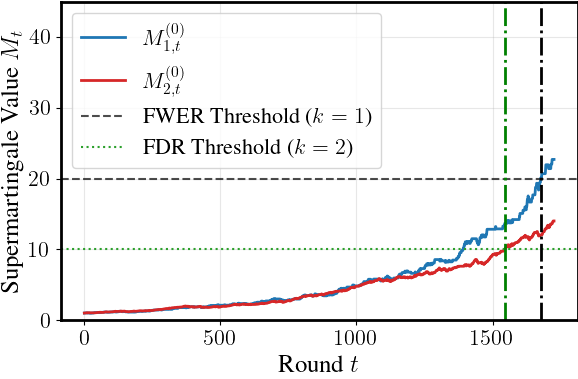

FDR DETECTION: Run 1, t=1397, k_t=2
  N_t values: {1: 0, 2: 2, 3: 2, 4: 2}
  Max ever values: [13.84292097  1.         10.0027085   1.        ]
  FDR threshold for k_t=2: 10.0
  Rejected hypotheses: ['P1_dev0', 'P2_dev0']


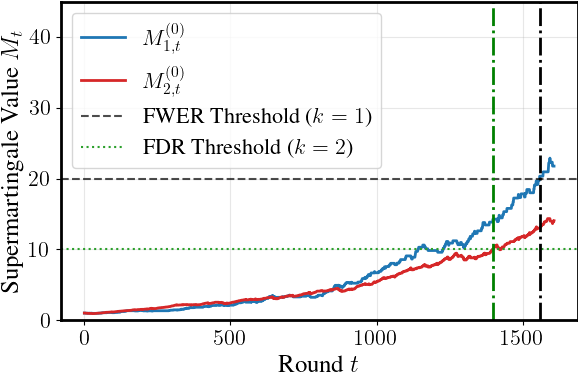

FDR DETECTION: Run 2, t=1360, k_t=2
  N_t values: {1: 0, 2: 2, 3: 2, 4: 2}
  Max ever values: [10.25684168  1.025      10.07597978  1.        ]
  FDR threshold for k_t=2: 10.0
  Rejected hypotheses: ['P1_dev0', 'P2_dev0']


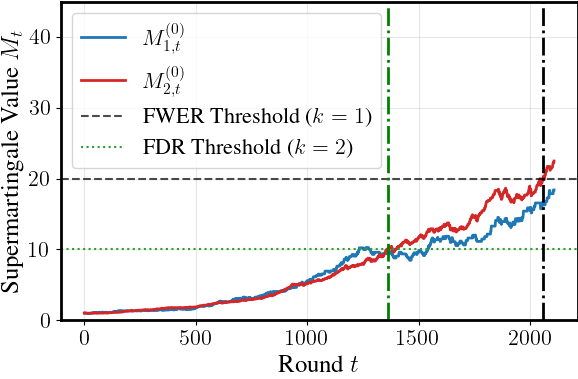

FDR DETECTION: Run 3, t=1583, k_t=2
  N_t values: {1: 0, 2: 2, 3: 2, 4: 2}
  Max ever values: [10.00298423  1.         16.11420533  1.        ]
  FDR threshold for k_t=2: 10.0
  Rejected hypotheses: ['P1_dev0', 'P2_dev0']


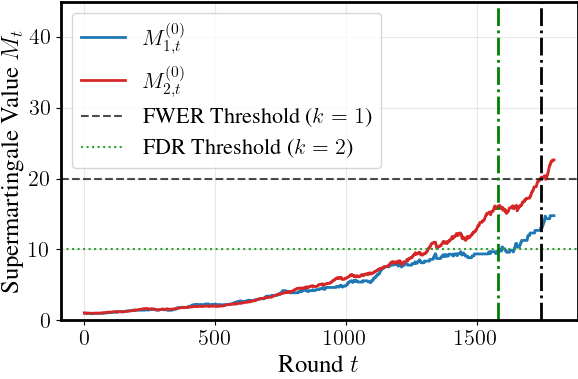

FDR DETECTION: Run 4, t=1547, k_t=1
  N_t values: {1: 1, 2: 1, 3: 2, 4: 2}
  Max ever values: [ 6.78098067  1.         20.1286531   1.        ]
  FDR threshold for k_t=1: 20.0
  Rejected hypotheses: ['P2_dev0']


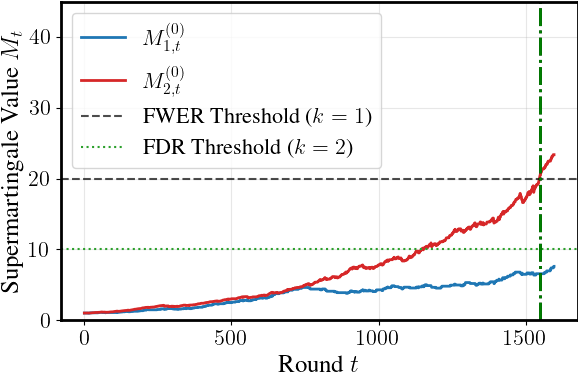

FDR DETECTION: Run 5, t=2010, k_t=2
  N_t values: {1: 0, 2: 2, 3: 2, 4: 2}
  Max ever values: [10.98542965  1.         10.0995327   1.        ]
  FDR threshold for k_t=2: 10.0
  Rejected hypotheses: ['P1_dev0', 'P2_dev0']


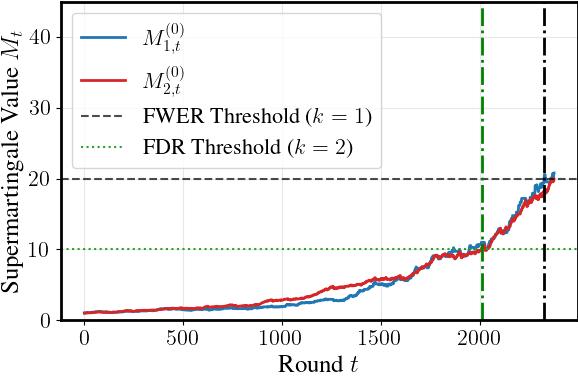

------- FWER vs FDR Comparison under Alternative -------
FWER average stopping time: 1765.4 ± 196.0
FDR average stopping time: 1545.4 ± 212.8

Detection rate (before max time 4000):
FWER: 100.0%
FDR: 100.0%

FDR speedup over FWER: 1.15x


C:\Users\etgauthi\AppData\Local\Temp\ipykernel_45392\2553331224.py:240: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


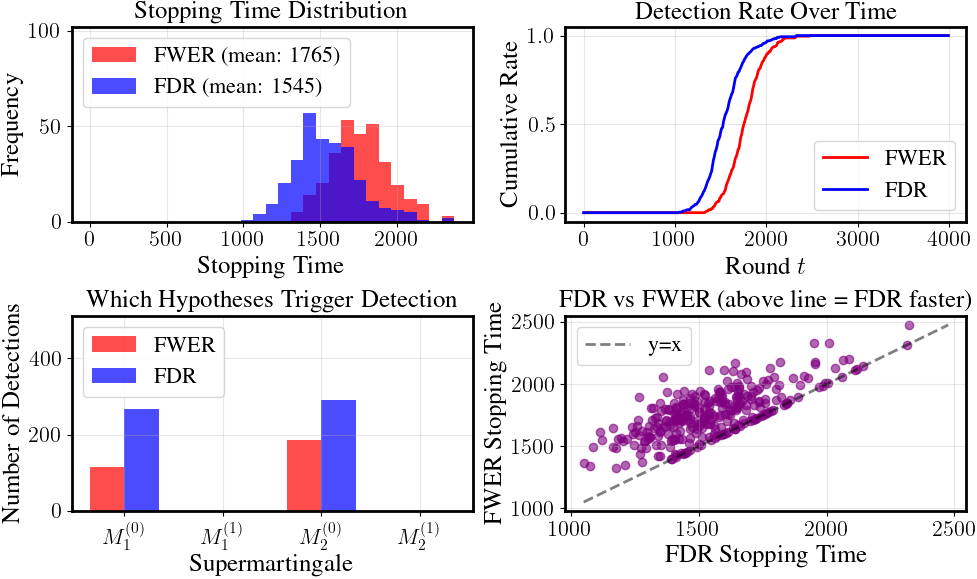


Summary: FDR detects deviations 1.15x faster than FWER on average
This demonstrates the practical advantage of FDR control for early detection


In [4]:
# compare FWER vs FDR stopping times under alternative

np.random.seed(0)

alpha = 0.2
threshold = sum(A_sizes)/alpha 

T_alt = 4000    # maximum rounds for alternative simulation
R_alt = 300     # number of runs for alternative
lambda_alt = 0.05

p_alt = 0.85
q_alt = 0.65
pi1_alt = np.array([p_alt, 1 - p_alt])  # P1's alt strategy
pi2_alt = np.array([q_alt, 1 - q_alt])  # P2's alt strategy

# FDR parameters
m = sum(A_sizes)  # total number of hypotheses = 4
gamma_uniform = 1/m  # uniform weights

# storage for stopping times
tau_fwer = np.full(R_alt, T_alt)  
tau_fdr = np.full(R_alt, T_alt) 
which_hypothesis_fwer = [] 
which_hypothesis_fdr = [] 

r_vis = 6 # runs to visualize (e.g., 6 first runs)

for r in range(R_alt):
    M1 = np.ones((2, T_alt+1))
    M2 = np.ones((2, T_alt+1))
    for t in range(1, T_alt+1):
        # sample actions from alternative distribution
        a1 = np.random.choice([0,1], p=pi1_alt)
        a2 = np.random.choice([0,1], p=pi2_alt)
        # P1
        for a1_prime in [0,1]:
            X1 = U1[a1, a2] - U1[a1_prime, a2]
            M1[a1_prime, t] = M1[a1_prime, t-1] * (1 - lambda_alt * X1)
        # P2
        for a2_prime in [0,1]:
            X2 = U2[a1, a2] - U2[a1, a2_prime]
            M2[a2_prime, t] = M2[a2_prime, t-1] * (1 - lambda_alt * X2)
        
        # FWER threshold
        if tau_fwer[r] == T_alt:  # have not rejected yet
            max_martingale = max(np.max(M1[:, t]), np.max(M2[:, t]))
            if max_martingale >= threshold:
                tau_fwer[r] = t
                # record which hypothesis triggered rejection
                triggering_hyp = []
                for i, a_prime in [(0,0), (0,1), (1,0), (1,1)]:
                    if i == 0 and M1[a_prime, t] >= threshold:
                        triggering_hyp.append(f"P1_dev{a_prime}")
                    elif i == 1 and M2[a_prime, t] >= threshold:
                        triggering_hyp.append(f"P2_dev{a_prime}")
                which_hypothesis_fwer.append(triggering_hyp)
        
        # FDR threshold
        if tau_fdr[r] == T_alt:  # have not rejected yet
            # track which hypotheses have ever exceeded their thresholds
            # we need to maintain this across time steps
            if t == 1:
                # initialize: track the maximum value seen so far for each hypothesis
                max_ever = np.ones(m)
                # and track which thresholds have been exceeded
                ever_exceeded = {k: set() for k in range(1, m+1)}
            
            # update max_ever for each hypothesis
            current_vals = []
            hypotheses = []
            for a1_prime in [0,1]:
                current_vals.append(M1[a1_prime, t])
                hypotheses.append(f"P1_dev{a1_prime}")
            for a2_prime in [0,1]:
                current_vals.append(M2[a2_prime, t])
                hypotheses.append(f"P2_dev{a2_prime}")
            
            current_vals = np.array(current_vals)
            max_ever = np.maximum(max_ever, current_vals)
            
            # update ever_exceeded sets for each k
            for k in range(1, m+1):
                threshold_k = 1 / (k * alpha * gamma_uniform)
                for i, (hyp, max_val) in enumerate(zip(hypotheses, max_ever)):
                    if max_val >= threshold_k:
                        ever_exceeded[k].add(hyp)
            
            # compute N_t(k) for each k: number of hypotheses that have ever exceeded 1/(k*alpha*gamma)
            N_t = {}
            for k in range(1, m+1):
                N_t[k] = len(ever_exceeded[k])
            # find k_t: largest k such that N_t(k) >= k
            k_t = 0
            for k in range(1, m+1):
                if N_t[k] >= k:
                    k_t = k
            if k_t > 0:
                tau_fdr[r] = t
                # rejection set: all hypotheses that have ever exceeded 1/(k_t*alpha*gamma)
                threshold_fdr_final = 1 / (k_t * alpha * gamma_uniform)
                rejected_hyp = [hyp for hyp, max_val in zip(hypotheses, max_ever) 
                            if max_val >= threshold_fdr_final]
                which_hypothesis_fdr.append(rejected_hyp)

                if r < r_vis:
                    print(f"FDR DETECTION: Run {r}, t={t}, k_t={k_t}")
                    print(f"  N_t values: {N_t}")
                    print(f"  Max ever values: {max_ever}")
                    print(f"  FDR threshold for k_t={k_t}: {threshold_fdr_final:.1f}")
                    print(f"  Rejected hypotheses: {rejected_hyp}")

    if r < r_vis:
        plt.figure(figsize=(6,4))

        # plotting ONLY the two true deviation martingales (P1_dev0 and P2_dev0)

        # P1_dev0
        plt.plot(M1[0, 0:tau_fwer[r]+50], label=r"$M_{1,t}^{(0)}$", 
                color='#1f77b4', linestyle='-', linewidth=2) 

        # P2_dev0
        plt.plot(M2[0, 0:tau_fwer[r]+50], label=r"$M_{2,t}^{(0)}$", 
                color='#d62728', linestyle='-', linewidth=2) 

        # plot FWER threshold (k=1)
        fwer_threshold = threshold
        plt.axhline(y=fwer_threshold, color='black', linestyle='--', linewidth=1.5, 
                    label='FWER Threshold ($k=1$)', alpha=0.7)

        # plot FDR k=2 threshold (The target rejection level)
        fdr_k2_threshold = 1 / (2 * alpha * gamma_uniform)
        plt.axhline(y=fdr_k2_threshold, color='#2ca02c', linestyle=':', linewidth=1.5, 
                    label='FDR Threshold ($k=2$)') 

        plt.ylim(0, max(45, np.max(M1[0, 0:tau_fwer[r]+50]) * 1.1) )
        
        plt.axvline(x=tau_fwer[r], color='black', linestyle='-.')
        
        plt.axvline(x=tau_fdr[r], color='green', linestyle='-.')

        plt.xlabel(r'Round $t$')
        plt.ylabel("Supermartingale Value $M_t$")
        plt.legend(loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"plots/normal-form/sample_detection_{r}.pdf", format="pdf", bbox_inches="tight")
        plt.show()


# Analysis of results
print("------- FWER vs FDR Comparison under Alternative -------")
print(f"FWER average stopping time: {np.mean(tau_fwer):.1f} ± {np.std(tau_fwer):.1f}")
print(f"FDR average stopping time: {np.mean(tau_fdr):.1f} ± {np.std(tau_fdr):.1f}")

fwer_detection_rate = np.sum(tau_fwer < T_alt) / R_alt
fdr_detection_rate = np.sum(tau_fdr < T_alt) / R_alt
print(f"\nDetection rate (before max time {T_alt}):")
print(f"FWER: {fwer_detection_rate:.1%}")
print(f"FDR: {fdr_detection_rate:.1%}")

# speedup
speedup = tau_fwer / np.maximum(tau_fdr, 1) 
speedup = speedup[(tau_fwer < T_alt) & (tau_fdr < T_alt)] 
if len(speedup) > 0:
    print(f"\nFDR speedup over FWER: {np.mean(speedup):.2f}x")

plt.figure(figsize=(10, 6))

# plot 1: stopping time distributions
plt.subplot(2, 2, 1)
bins = np.linspace(0, min(np.max(tau_fwer[tau_fwer < T_alt]), 
                         np.max(tau_fdr[tau_fdr < T_alt])) + 50, 30)
plt.hist(tau_fwer[tau_fwer < T_alt], bins=bins, alpha=0.7, 
         label=f'FWER (mean: {np.mean(tau_fwer[tau_fwer < T_alt]):.0f})', color='red')
plt.hist(tau_fdr[tau_fdr < T_alt], bins=bins, alpha=0.7, 
         label=f'FDR (mean: {np.mean(tau_fdr[tau_fdr < T_alt]):.0f})', color='blue')
plt.xlabel('Stopping Time')
plt.ylabel('Frequency')
plt.ylim(0,102)
plt.legend(loc='upper left')
plt.title('Stopping Time Distribution')
plt.grid(True, alpha=0.3)

# plot 2: cumulative detection over time
plt.subplot(2, 2, 2)
time_points = np.arange(1, T_alt+1, 10)
fwer_cumulative = [np.sum(tau_fwer <= t) / R_alt for t in time_points]
fdr_cumulative = [np.sum(tau_fdr <= t) / R_alt for t in time_points]

plt.plot(time_points, fwer_cumulative, label='FWER', color='red', linewidth=2)
plt.plot(time_points, fdr_cumulative, label='FDR', color='blue', linewidth=2)
plt.xlabel('Round $t$')
plt.ylabel('Cumulative Rate')
plt.legend(loc='lower right')
plt.title('Detection Rate Over Time')
plt.grid(True, alpha=0.3)

# plot 3: which hypotheses are detected
plt.subplot(2, 2, 3)
hypotheses = ['P1_dev0', 'P1_dev1', 'P2_dev0', 'P2_dev1']
fwer_detected = [0] * 4
fdr_detected = [0] * 4

for hyp_list in which_hypothesis_fwer:
    for hyp in hyp_list:
        idx = hypotheses.index(hyp)
        fwer_detected[idx] += 1

for hyp_list in which_hypothesis_fdr:
    for hyp in hyp_list:
        idx = hypotheses.index(hyp)
        fdr_detected[idx] += 1

x_pos = np.arange(len(hypotheses))
width = 0.35
plt.bar(x_pos - width/2, fwer_detected, width, label='FWER', alpha=0.7, color='red')
plt.bar(x_pos + width/2, fdr_detected, width, label='FDR', alpha=0.7, color='blue')
plt.xlabel('Supermartingale')
plt.ylabel('Number of Detections')
plt.xticks(x_pos, [r'$M_1^{(0)}$',r'$M_1^{(1)}$',r'$M_2^{(0)}$',r'$M_2^{(1)}$'])
plt.legend(loc='upper left')
plt.ylim(0,510)
plt.title('Which Hypotheses Trigger Detection')
plt.grid(True, alpha=0.3)

# plot 4: FDR vs FWER stopping times scatter
plt.subplot(2, 2, 4)
both_detected = (tau_fwer < T_alt) & (tau_fdr < T_alt)
plt.scatter(tau_fdr[both_detected], tau_fwer[both_detected], alpha=0.6, color='purple')
max_val = max(np.max(tau_fwer[both_detected]), np.max(tau_fdr[both_detected]))
min_val = min(np.min(tau_fwer[both_detected]), np.min(tau_fdr[both_detected]))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='y=x')
plt.xlabel('FDR Stopping Time')
plt.ylabel('FWER Stopping Time')
plt.legend()
plt.title('FDR vs FWER (above line = FDR faster)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("plots/normal-form/fwer_vs_fdr_comparison.pdf", format="pdf", bbox_inches="tight")
plt.show()

print(f"\nSummary: FDR detects deviations {np.mean(speedup):.2f}x faster than FWER on average")
print("This demonstrates the practical advantage of FDR control for early detection")

In [5]:
plt.rcParams.update(bundles.icml2024())
plt.rcParams.update({
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "lines.linewidth": 2.5,
    "axes.linewidth": 2,
})

# game definitions

# payoffs
U1 = np.array([[0.9, 0.2], [0.3, 0.7]])
U2 = np.array([[0.5, 0.3], [0.2, 0.7]])

# H0: NE strategies
pi1_ne = np.array([5/7, 2/7])
pi2_ne = np.array([5/11, 6/11])
pi_ne = [pi1_ne, pi2_ne]

# H1: alternative strategies
pi_alts = {
    0.05: (np.array([0.9, 0.1]), np.array([10/11, 1/11])), 
    0.1: (np.array([0.8, 0.2]), np.array([10/11, 1/11])), 
    0.15: (np.array([0.7, 0.3]), np.array([10/11, 1/11])), 
}

# simulation parameters
T = 4000  # number of rounds per run
R = 300   # number of independent runs
A_sizes = [2, 2]
m = sum(A_sizes)

# parameter grids
alphas = [0.2, 0.1, 0.05]
lambdas = [0.05, 0.1, 0.15, 0.4]
target_etas = [0.05, 0.10, 0.15]

np.random.seed(42)

# FWER control (H0)

print("="*70)
print("FWER CONTROL STUDY (under H0)")
print("="*70)
print("Lambda | Alpha | FWER Threshold (u) | Emp. FWER Rate")
print("-"*70)

colors_player1 = ["#1f77b4", "#2ca02c"] 
colors_player2 = ["#d62728", "#ff7f0e"] 

for lambda_val in lambdas:
    # storage for this lambda's simulation
    M1_all = np.ones((R, 2, T+1))
    M2_all = np.ones((R, 2, T+1))
    
    for r in range(R):
        M1 = np.ones((2, T+1))
        M2 = np.ones((2, T+1))
        for t in range(1, T+1):
            a1 = np.random.choice([0,1], p=pi_ne[0])
            a2 = np.random.choice([0,1], p=pi_ne[1])
            for a1_prime in [0,1]:
                X1 = U1[a1, a2] - U1[a1_prime, a2]
                M1[a1_prime, t] = M1[a1_prime, t-1] * (1 - lambda_val * X1)
            for a2_prime in [0,1]:
                X2 = U2[a1, a2] - U2[a1, a2_prime]
                M2[a2_prime, t] = M2[a2_prime, t-1] * (1 - lambda_val * X2)
        M1_all[r] = M1
        M2_all[r] = M2
    
    # plotting H0 results (one plot per lambda)
    plt.figure(figsize=(8, 5))
    
    for r in range(R):
        plt.plot(M1_all[r, 0], color=colors_player1[0], alpha=0.1)
        plt.plot(M1_all[r, 1], color=colors_player1[1], alpha=0.1)
        plt.plot(M2_all[r, 0], color=colors_player2[0], alpha=0.1, linestyle='--')
        plt.plot(M2_all[r, 1], color=colors_player2[1], alpha=0.1, linestyle='--')
    
    # proxy lines for legend
    plt.plot([], [], color=colors_player1[0], linestyle='-', label=r"$M_1^{(0)}$")
    plt.plot([], [], color=colors_player1[1], linestyle='-', label=r"$M_1^{(1)}$")
    plt.plot([], [], color=colors_player2[0], linestyle='--', label=r"$M_2^{(0)}$")
    plt.plot([], [], color=colors_player2[1], linestyle='--', label=r"$M_2^{(1)}$")

    # plot all alpha thresholds
    for alpha in alphas:
        threshold = m / alpha
        plt.axhline(y=threshold, color='black', linestyle=':', linewidth=2, alpha=0.9)
        plt.text(T * 0.98, threshold, f" b ($\\alpha={alpha}$)", 
                 ha='right', va='bottom', fontsize=14, color='black')

    plt.xlabel("Round $t$")
    plt.ylabel("Supermartingale Value $M_t$")
    plt.legend(frameon=True, framealpha=1, loc='upper left', ncol=1)
    plt.xlim(0, T)
    plt.ylim(0, 160) 
    plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    plot_filename = f"plots/normal-form/fwer_control_lambda_{lambda_val}.pdf"
    plt.tight_layout()
    plt.savefig(plot_filename, format="pdf", bbox_inches="tight")
    plt.close()

    # FWERs
    max_M1_all = np.max(M1_all, axis=(1, 2)) 
    max_M2_all = np.max(M2_all, axis=(1, 2))
    max_per_run = np.maximum(max_M1_all, max_M2_all)
    
    for alpha in alphas:
        threshold = m / alpha
        rejections = np.sum(max_per_run >= threshold)
        empirical_fwer = rejections / R
        print(f"{lambda_val:6} | {alpha:5} | {threshold:18.1f} | {empirical_fwer:14.3f}")

# alternative detection study (H1)

print("\n" + "="*70)
print("DETECTION TIME STUDY (under H1)")
print("="*70)
print("Target Eta | Alpha | Lambda | FWER Threshold (u) | Avg. FWER Stop Time (Mean [Q1, Q3])")
print("-"*70)

# store results for plotting
h1_results_mean = {} # {(eta, alpha): [list_of_avg_taus_for_each_lambda]}
h1_results_q1 = {}   # {(eta, alpha): [list_of_q1_taus_for_each_lambda]}
h1_results_q3 = {}   # {(eta, alpha): [list_of_q3_taus_for_each_lambda]}

for eta_target in target_etas:
    pi1_alt, pi2_alt = pi_alts[eta_target]

    for alpha in alphas:
        threshold = m / alpha
        
        # lists to store stats for each lambda
        mean_taus_per_lambda = [] 
        q1_taus_per_lambda = []
        q3_taus_per_lambda = []
        
        for lambda_val in lambdas:
            tau_ubs = np.full(R, T)
            
            for r in range(R):
                M1 = np.ones((2, T+1))
                M2 = np.ones((2, T+1))
                
                for t in range(1, T+1):
                    if tau_ubs[r] < T: 
                        break
                    a1 = np.random.choice([0,1], p=pi1_alt)
                    a2 = np.random.choice([0,1], p=pi2_alt)
                    for a1_prime in [0,1]:
                        if M1[a1_prime, t-1] < threshold:
                            X1 = U1[a1, a2] - U1[a1_prime, a2]
                            M1[a1_prime, t] = M1[a1_prime, t-1] * (1 - lambda_val * X1)
                        else:
                            M1[a1_prime, t] = M1[a1_prime, t-1]
                    for a2_prime in [0,1]:
                        if M2[a2_prime, t-1] < threshold:
                            X2 = U2[a1, a2] - U2[a1, a2_prime]
                            M2[a2_prime, t] = M2[a2_prime, t-1] * (1 - lambda_val * X2)
                        else:
                             M2[a2_prime, t] = M2[a2_prime, t-1]

                    if np.any(M1[:, t] >= threshold) or np.any(M2[:, t] >= threshold):
                        tau_ubs[r] = t
            
            # calculate mean and quantiles
            avg_tau_ub = np.mean(tau_ubs)
            q1_tau_ub = np.percentile(tau_ubs, 25)
            q3_tau_ub = np.percentile(tau_ubs, 75)
            
            mean_taus_per_lambda.append(avg_tau_ub)
            q1_taus_per_lambda.append(q1_tau_ub)
            q3_taus_per_lambda.append(q3_tau_ub)
            
            print(f"{eta_target:10.2f} | {alpha:5} | {lambda_val:6} | {threshold:18.1f} | {avg_tau_ub:10.1f} (IQR: [{q1_tau_ub:6.1f}, {q3_tau_ub:6.1f}])")
        
        # store lists in dictionaries
        h1_results_mean[(eta_target, alpha)] = mean_taus_per_lambda
        h1_results_q1[(eta_target, alpha)] = q1_taus_per_lambda
        h1_results_q3[(eta_target, alpha)] = q3_taus_per_lambda

eta_colors = ["#1f77b4", "#d62728", "#2ca02c"]

for i, alpha in enumerate(alphas):
    plt.figure(figsize=(7, 5))
    
    for j, eta_target in enumerate(target_etas):
        avg_taus = h1_results_mean[(eta_target, alpha)]
        q1_taus = h1_results_q1[(eta_target, alpha)]
        q3_taus = h1_results_q3[(eta_target, alpha)]
        
        color = eta_colors[j]
        
        plt.plot(lambdas, avg_taus, label=f"$\\eta = {eta_target}$", 
                 color=color, marker='o', markersize=8)
        
        plt.fill_between(lambdas, q1_taus, q3_taus, 
                         color=color, alpha=0.2)

    plt.xlabel("Betting Parameter $\\lambda$")
    plt.ylabel("Avg. FWER Stopping Time") 
    plt.legend(frameon=True, framealpha=1, loc='upper right')
    plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    plt.ylim(10, 10000) 
    plt.yscale('log') 
    
    plt.xticks(lambdas)
    
    plot_filename = f"plots/normal-form/h1_detection_time_alpha_{alpha}.pdf"
    plt.tight_layout()
    plt.savefig(plot_filename, format="pdf", bbox_inches="tight")
    plt.close()

FWER CONTROL STUDY (under H0)
Lambda | Alpha | FWER Threshold (u) | Emp. FWER Rate
----------------------------------------------------------------------


C:\Users\etgauthi\AppData\Local\Temp\ipykernel_45392\1163160428.py:104: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


  0.05 |   0.2 |               20.0 |          0.010
  0.05 |   0.1 |               40.0 |          0.000
  0.05 |  0.05 |               80.0 |          0.000
   0.1 |   0.2 |               20.0 |          0.077
   0.1 |   0.1 |               40.0 |          0.037
   0.1 |  0.05 |               80.0 |          0.007
  0.15 |   0.2 |               20.0 |          0.100
  0.15 |   0.1 |               40.0 |          0.050
  0.15 |  0.05 |               80.0 |          0.027
   0.4 |   0.2 |               20.0 |          0.153
   0.4 |   0.1 |               40.0 |          0.077
   0.4 |  0.05 |               80.0 |          0.030

DETECTION TIME STUDY (under H1)
Target Eta | Alpha | Lambda | FWER Threshold (u) | Avg. FWER Stop Time (Mean [Q1, Q3])
----------------------------------------------------------------------
      0.05 |   0.2 |   0.05 |               20.0 |     1236.0 (IQR: [1148.5, 1317.8])
      0.05 |   0.2 |    0.1 |               20.0 |      631.4 (IQR: [ 567.2,  688.8])
 

C:\Users\etgauthi\AppData\Local\Temp\ipykernel_45392\1163160428.py:216: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
